In [49]:
#Imports
import numpy as np
from numcompute_stream.tree import DecisionTreeClassifier
from numcompute_stream.ensemble import EnsembleClassifier
from numcompute_stream.stream import StreamTrainer
from numcompute_stream.preprocessing import StandardScaler
from numcompute_stream.metrics import StreamMetrics
from numcompute_stream.stats import StreamStats
from numcompute_stream.pipeline import Pipeline
from numcompute_stream.visualise import (
    plot_metric_over_time,
    compare_models,
    plot_predictions_vs_ground_truth,
)
from numcompute_stream.io import load_csv

In [50]:
#Loading the dataset

data = load_csv("../test.csv", skip_header=1)

X_raw = data[:, :-1].astype(float)
y_raw = data[:, -1].astype(float).astype(int)

print(f"Dataset shape : {X_raw.shape}")
print(f"Classes       : {np.unique(y_raw)}")
print(f"First 3 rows  :\n{X_raw[:3]}")

Dataset shape : (98, 4)
Classes       : [0 1]
First 3 rows  :
[[2.3 1.5 0.8 3.1]
 [1.1 2.4 1.2 0.9]
 [3.5 0.8 2.1 1.4]]


In [51]:
#Split into chunks to simulate streaming
chunk_size = 20
n_samples = X_raw.shape[0]

chunks_X = [X_raw[i:i + chunk_size] for i in range(0, n_samples, chunk_size)]
chunks_y = [y_raw[i:i + chunk_size] for i in range(0, n_samples, chunk_size)]

print(f"Total samples : {n_samples}")
print(f"Chunk size    : {chunk_size}")
print(f"Total chunks  : {len(chunks_X)}")

Total samples : 98
Chunk size    : 20
Total chunks  : 5


In [52]:
# Train incrementally using Pipeline with partial_fit

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", DecisionTreeClassifier(max_depth=5, criterion="gini"))
])

for X_chunk, y_chunk in zip(chunks_X, chunks_y):
    pipe.partial_fit(X_chunk, y_chunk)

print("Pipeline trained incrementally over chunks using partial_fit()")
print(f"Steps : {[name for name, _ in pipe.steps]}")

Pipeline trained incrementally over chunks using partial_fit()
Steps : ['scaler', 'model']


In [53]:
#Set up pipeline and StreamTrainer with DecisionTree
scaler = StandardScaler()
scaler.fit(X_raw)

tree_model = DecisionTreeClassifier(max_depth=5, criterion="gini")
tree_trainer = StreamTrainer(model=tree_model)

print("StreamTrainer with DecisionTreeClassifier ready.")

StreamTrainer with DecisionTreeClassifier ready.


In [54]:
# Train incrementally chunk by chunk
for X_chunk, y_chunk in zip(chunks_X, chunks_y):
    tree_trainer.fit_chunk(X_chunk, y_chunk)

logs = tree_trainer.get_logs()
print(f"Chunks processed : {len(logs)}")
print(f"Final cumulative accuracy : {logs[-1]['cumulative_accuracy']:.4f}")

Chunks processed : 5
Final cumulative accuracy : 1.0000


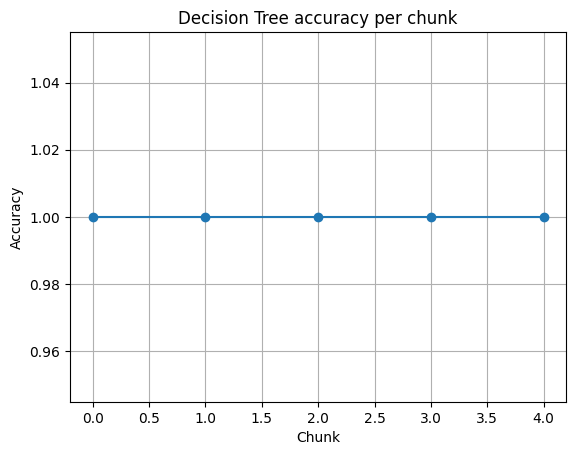

In [55]:
# Plot accuracy over time for tree
accuracies = [log["accuracy"] for log in logs]
plot_metric_over_time(
    accuracies,
    title="Decision Tree accuracy per chunk",
    ylabel="Accuracy",
)

In [56]:
# Set up and train EnsembleClassifier
ensemble_model = EnsembleClassifier(n_trees=10, method="random_forest", max_depth=5)
ensemble_trainer = StreamTrainer(model=ensemble_model)

for X_chunk, y_chunk in zip(chunks_X, chunks_y):
    ensemble_trainer.fit_chunk(X_chunk, y_chunk)

ensemble_logs = ensemble_trainer.get_logs()
print(f"Chunks processed : {len(ensemble_logs)}")
print(f"Final cumulative accuracy : {ensemble_logs[-1]['cumulative_accuracy']:.4f}")

Chunks processed : 5
Final cumulative accuracy : 1.0000


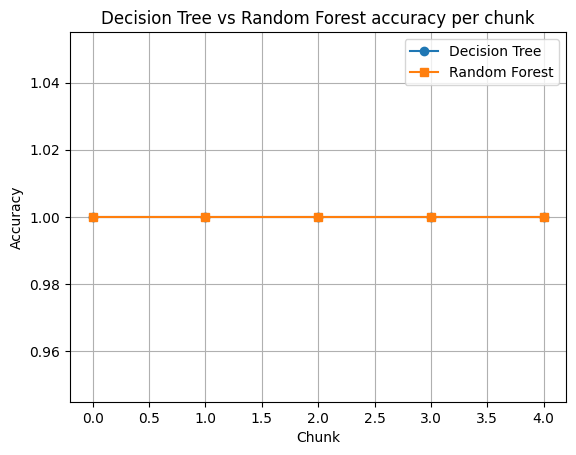

In [57]:
# Compare tree vs ensemble accuracy
tree_accuracies = [log["accuracy"] for log in logs]
ensemble_accuracies = [log["accuracy"] for log in ensemble_logs]

compare_models(
    tree_accuracies,
    ensemble_accuracies,
    labels=["Decision Tree", "Random Forest"],
    title="Decision Tree vs Random Forest accuracy per chunk",
    ylabel="Accuracy",
)

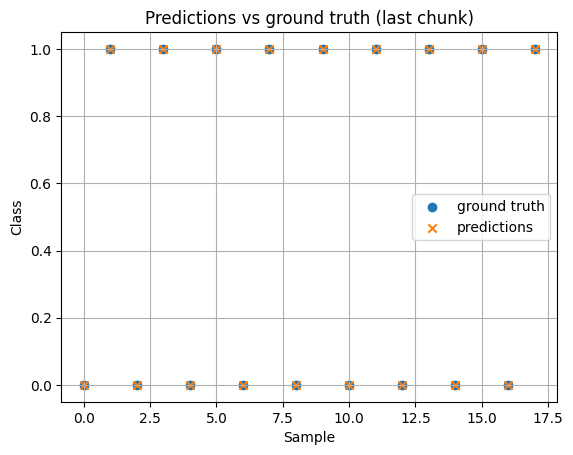

In [58]:
# Predictions vs ground truth on last chunk
last_X = chunks_X[-1]
last_y = chunks_y[-1]

tree_preds = tree_model.predict(last_X)
plot_predictions_vs_ground_truth(
    last_y,
    tree_preds,
    title="Predictions vs ground truth (last chunk)",
)

In [59]:
#  StreamMetrics summary
sm = StreamMetrics()

for X_chunk, y_chunk in zip(chunks_X, chunks_y):
    preds = tree_model.predict(X_chunk)
    sm.update(y_chunk, preds)

result = sm.result()
print("=== StreamMetrics Summary (Decision Tree) ===")
print(f"Accuracy  : {result['accuracy']:.4f}")
print(f"Precision : {result['precision']:.4f}")
print(f"Recall    : {result['recall']:.4f}")
print(f"F1        : {result['f1']:.4f}")
print(f"AUC       : {result['auc']:.4f}")
print(f"Confusion Matrix:\n{result['confusion_matrix']}")

=== StreamMetrics Summary (Decision Tree) ===
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1        : 1.0000
AUC       : 1.0000
Confusion Matrix:
[[50  0]
 [ 0 48]]


In [60]:
# StreamStats summary
ss = StreamStats(n_features=X_raw.shape[1])

for X_chunk in chunks_X:
    ss.update_stats(X_chunk)

stats_result = ss.result()
print("=== StreamStats Summary ===")
print(f"Mean     : {stats_result['mean']}")
print(f"Std      : {stats_result['std']}")
print(f"Min      : {stats_result['min']}")
print(f"Max      : {stats_result['max']}")

=== StreamStats Summary ===
Mean     : [2.62040816 1.92755102 1.87959184 1.75102041]
Std      : [1.44307512 1.14502785 1.26881381 1.04153385]
Min      : [0.5 0.5 0.2 0.4]
Max      : [4.9 4.2 3.9 3.7]


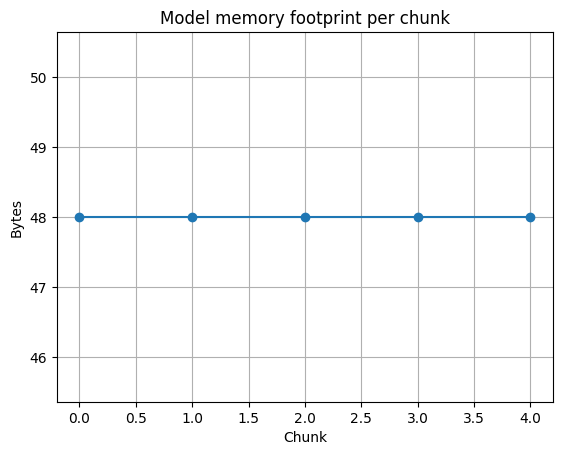

In [61]:
#  Memory footprint log
memory_log = [log["memory_bytes"] for log in logs]
plot_metric_over_time(
    memory_log,
    title="Model memory footprint per chunk",
    ylabel="Bytes",
)